In [133]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')
    
    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)
    
        

    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)
    

def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):
    
    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]
    
    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)
    
    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')
    
    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])

    
    return X_train,y_train,X_val,y_val,X_test,y_test

In [134]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2


In [135]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

/var/folders/_v/x5b_z33d0jl6zxyg2m57g41c0000gp/T/ipykernel_84036/4062928930.py:22: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo,encoding='latin1')


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


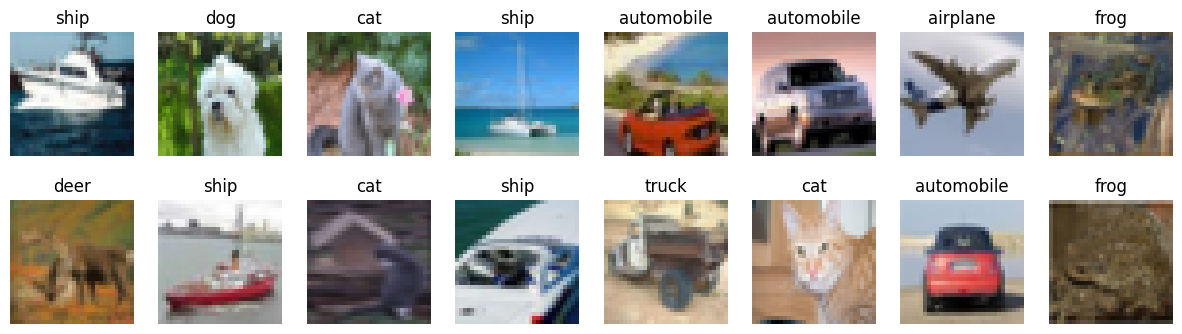

In [136]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [137]:
# mirroring training images by their vertical axis, to have a bigger dataset for training

x_train_new = []
for m in range(0, len(x_train)):
    x_train_new_i = np.fliplr(x_train[m])
    x_train_new.append(x_train_new_i )

x_train_new_nparr = np.array(x_train_new)
print(x_train_new_nparr.shape)  #printing the shape of this array to make sure it has the same dimensions as the original x_train array


(40000, 32, 32, 3)


First making a normal array of the flipped images and then turning that array into a numpy-array might include one step that is not necessary, however it was easier for me to do it this way, because I am more used to how to work with (eg append) normal arrays than how to work with numpy-arrays. Since this method worked, I decided to keep it this way and rather invest my time into training the model than to change this to a slightly more efficient solution.

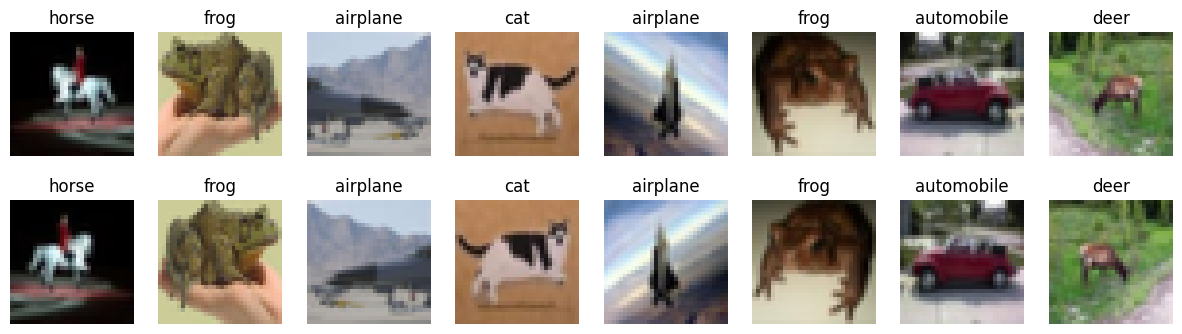

In [138]:
# show random images from x_train and x_train_new_nparr, and their labels to check if the correct pictures were flipped the correct way
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
rand_ind_arr = []
m=0
for i in range(cols):
    
    for j in range(rows):
        
        if 0<=i<4:
            random_index = np.random.randint(0, len(y_train))
            rand_ind_arr.append(random_index)
            ax = fig.add_subplot(2, cols, i * rows + j + 1)
            ax.grid('off')
            ax.axis('off')
            ax.imshow(x_train[random_index, :])
            ax.set_title(cifar10_classes[y_train[random_index]])
        #
        if 4<=i<cols:
            ax = fig.add_subplot(2, cols, i * rows + j + 1)
            ax.grid('off')
            ax.axis('off')
            ax.imshow(x_train_new_nparr[rand_ind_arr[m], :])
            ax.set_title(cifar10_classes[y_train[rand_ind_arr[m]]])
            m+=1    # to iterate throught the array of random integers
plt.show()


In [ ]:
# append x_train and y_train by the new images

print("Shape of x_train before appending:", x_train.shape)  # printing the shapes before and after appending to make sure they have the correct shape
print("Shape of x_train_new_nparr before appending:", x_train_new_nparr.shape)
x_train = np.append(x_train, x_train_new_nparr, axis=0)
print("Shape of x_train after appending:", x_train.shape)


y_train = np.append(y_train, y_train)   # the new images are in the same order as before, so y_train just has to be appended by y_train
print("Shape of y_train after appending:", y_train.shape)


Shape of x_train before appending: (40000, 32, 32, 3)
Shape of x_train_new_nparr before appending: (40000, 32, 32, 3)
Shape of x_train after appending: (80000, 32, 32, 3)
Shape of y_train after appending: (80000,)


I am above taking the part of the dataset for the training, flipping the images around their vertical axis and then adding that new array of flipped images (x_train_new_nparr) to the end of the image array from before (x_train), and the labels (y_train) to the label-array from before (y_train). This way, the dataset used for training contains twice the number of images as it did before, which helps a lot when training the model. I chose to only flip the images around their vertical axis and not in any other direction or any rotation, because none of the animals or objects in the pictures are usually seen upside down, so I did not feel like it makes sense to make the training dataset more complicated than the testing dataset (or any usual dataset) is going to be.

In [140]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [141]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

In [142]:
from tensorflow.keras import datasets, layers, models

In [143]:
from keras.layers import BatchNormalization

In [144]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()

    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network. 
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.
    

    INPUT_SHAPE = (32,32,3)

    # CNN-layer with keras.layer.Conv2D (from https://keras.io/api/layers/convolution_layers/convolution2d/)
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", strides=2, input_shape=INPUT_SHAPE)) #, dilation_rate=(1, 1) #activation='relu'
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", strides=1))    #activation='relu' 
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", strides=1))    #activation='relu' 
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Dropout(rate=0.2))

    # pooling layer (from https://keras.io/api/layers/pooling_layers/max_pooling2d/)
    model.add(MaxPooling2D(pool_size=(2, 2)))

    
    # second set of layers
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", strides=1))    #activation='relu' 
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", strides=1))    #activation='relu' 
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Dropout(rate=0.2))

    model.add(MaxPooling2D(pool_size=(2, 2)))
    

    # Dense NN layer
    model.add(Flatten())

    model.add(Dense(units=512)) 
    model.add(LeakyReLU())
    
    model.add(Dense(units=256)) 
    model.add(LeakyReLU())

    model.add(Dropout(rate=0.2))

    model.add(Dense(units=128)) 
    model.add(LeakyReLU())

    model.add(Dense(units=10))

    
    ### END STUDENT CODE ### 

    # Ensure normalized probabilities over the 10 classes
    model.add(Activation("softmax")) 

    return model

**Resources:**
-  conv2d: https://keras.io/api/layers/convolution_layers/convolution2d/
-  maxpooling2d: https://keras.io/api/layers/pooling_layers/max_pooling2d/
-  dropout: https://keras.io/api/layers/regularization_layers/dropout/
-  batch normalization: https://keras.io/api/layers/normalization_layers/batch_normalization/
-  LeakyReLU: https://keras.io/api/layers/activation_layers/leaky_relu/



**Description of the iteration path:**

*Convolution layers (conv2d):*
All of the convolution layers I used are using a 3x3 kernel. These kernels are going over the grid of the picture and are that way "scanning" the surroundings of (almost) each pixel in the image. In each kernel the values of the contained pixels are added up or subtracted in a specific way. The resulting values are then given to the next function also in form of a grid like the image was before. This process allows to gain information on shapes, for example if there is a corner or edge that could be related to the objects in the images. If the strides parameter is set to 2 instead of one, that means that the function is not going step by step from one pixel to the other, but is going two steps each time, so skipping every second pixel.

*Maxpooling layers (maxpooling2d):*
This function in my case cuts the image into 2x2 pieces and then in each of these pieces keeps the highest value score. These remaining values are put back together and then given to the next function as a version of the "image" that is smaller than before. I imagine this to mainly not relate to shapes but to colours in each of the small pieces of the image.

*Dropout layers:*
The dropout layers specify how much of the the learned values of the weightings between the nodes are re-evalued and changed for each leaning step and how many are kept the same way as before. This is supposed to prevent the function from overfitting too quickly before it has actually learned the patterns needed to recongnize the image. If the rate is set to 0.2, 20% of the inputs are not considered.

*Dense layers:*
Dense layers are connecting all input with every neuron in that layer. The number of units specifies the number of nodes that layer has. The final dense layer has ten node, because we want to sort every image to one of the ten possibilities.

*LeakyReLU:*
LeakyReLU specifies the activation used in the layers before. Activation functions make the model non-linear. They perform a function on the output of a node, which makes it possible for the model to learn patterns. (https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/)


*Batch normalization:*
This function is normalizing the output of a node such that the mean is about zero and the std about 1.


*Why my model is structured like this:*
I started off with the simple setup described in the comments provided to us (conv2d, maxpooling2d, flatten, dense). Then I slowly worked my way forward by testing additional layers or other parameters in the functions and after each training I decided if I would want to keep that change or if I go back to the version before (see my notes for this process below). Finally, I ended up with the following setup: conv2d, BatchNormalization, LeakyReLU, conv2d, BatchNormalization, LeakyReLU, conv2d, BatchNormalization, LeakyReLU, Dropout, maxpooling, Flatten, Dense, LeakyReLU, Dropout, Dense, LeakyReLU, Dense.



In [145]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training

INIT_LR = 5e-3  # initial learning rate
BATCH_SIZE = 128
EPOCHS = 100



K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR, beta_1=0.9, beta_2=0.99, epsilon=1e-07, weight_decay=None),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)

# function to stop the fitting if val_accuracy is not increasing by 0.0001 over 10 epochs
callback = keras.callbacks.EarlyStopping("val_accuracy", 0.0001, 10)     

# fit model
model.fit(
    x_train, y_train,  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=callback
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.4627 - loss: 1.5236 - val_accuracy: 0.5755 - val_loss: 1.1763
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.6426 - loss: 1.0166 - val_accuracy: 0.6704 - val_loss: 0.9571
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6988 - loss: 0.8640 - val_accuracy: 0.6987 - val_loss: 0.8855
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7279 - loss: 0.7771 - val_accuracy: 0.6865 - val_loss: 0.9277
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.7473 - loss: 0.7195 - val_accuracy: 0.7295 - val_loss: 0.7979
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.7654 - loss: 0.6747 - val_accuracy: 0.7358 - val_loss: 0.8008
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7762 - loss: 0.6428 - val_accuracy: 0.7587 - val_loss: 0.7289
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.7859 - loss: 0

Resources:
-  callback/stopping function: https://keras.io/api/callbacks/early_stopping/
-  for the different optimizers I tried: https://keras.io/api/optimizers/ 


My leaning process/changing things in the model- and leaning-structure step by step to see what works and what doesn't:

Init_lr:    model-shape:  batch size:  number epochs:  final val_accuracy:
-  5e-4    conv2d, maxpooling2d, conv2d, maxpooling2d  32 20  0.5058
-  5e-4    conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  32 20  0.5064
-  5e-3    conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  32 20  0.6070    (reached over 50% in the 8th epoch, but increased only very slowly after the 11th)
-  5e-2    conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  32 20  0.1031    (way to big step size)
-  5e-3    conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  128 20   0.5767
-  5e-3    conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5813 (max val_accuracy: 0.5846 at epoch 19)

-  5e-3    conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d, conv2d, maxpooling2d  128 40   0.6336    accuracy: 0.7290
-  5e-3    conv2d, maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5896    accuracy: 0.6140 (it seems like the dropout where it was before does not make a big difference at the moment)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5399    accuracy: 0.5515 (makes a huge difference in the time it takes and "only" about 4% less accuracy)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5654    accuracy: 0.6067 (the optimizer was changed to RMSprop with default values to see if the model improves; very slow improvements in the beginning, but in total it does improve a bit in the end)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.0968    accuracy: 0.1010 (RMSprop at rho=0.8 to see what happens; very bad outcome, it thinks everything is a bird, I will change it again)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.1026    accuracy: 0.0982 (RMSprop at rho=0.95, also very bad outcome, now everything is a horse)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.0966    accuracy: 0.1000 (again at RMSprop rho=0.9, still very bad outcome, maybe the system got overtrained?)

-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5640    accuracy: 0.6050 (again at RMSprop rho=0.9, improves only slowly towards the end, so I dont think running more epochs would make sense, but I'll try anyway just to be sure)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.0968    accuracy: 0.1009  (the second time I run this again absolutely no good outcome, maybe I am using the RMSprop function wrong?)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5539    accuracy: 0.5475   (back to Adamax with default-values, is a bit slower but seems to work better)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5356    accuracy: 0.5419
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.5003    accuracy: 0.4941 (checking if it makes sense at this point to add more layers, but it does not seem to help)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.5762 accuracy: 0.6062 (less layers actually do better at the moment)
-  5e-3    conv2d (strides=1), maxpooling2d, conv2d, maxpooling2d  128 20   0.5868 accuracy: 0.6295 (slightly better as before, the biggest increases in accuracy is happening in the first 10 epochs, so I am now trying out how I can keep that pace a bit longer)
Changing the first dense layer from 128 to 256 units: 5e-3    conv2d (strides=1), maxpooling2d, conv2d, maxpooling2d  128 20   0.6017 accuracy: 0.6802
-   5e-3    conv2d (strides=1), maxpooling2d, conv2d, maxpooling2d  128 20   0.6081 accuracy: 0.6788 (Adamax beta1=0.8, results about the same as before, so I might as well see what happens if i change beta1 further)
-  5e-3    conv2d (strides=1), maxpooling2d, conv2d, maxpooling2d  128 20   0.5903 accuracy: 0.6700 (beta1=0.7)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.5581 accuracy: 0.5827 (beta1=0.6)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.5962 accuracy: 0.6625 (beta1=0.8, beta2=0.9) (beta1=0.8 had the best results before, and I thought it could make sense to test the influence of beta2 as well )
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.6161 accuracy: 0.6874 (beta1=0.8, beta2=0.8) (slightly better than before)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.0966 accuracy: 0.0971 (beta1=0.8, beta2=0.7) (again really bad results)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.66 accuracy: 0.6892 (beta1=0.8, beta2=0.8)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d  128 20   0.5172 accuracy: 0.5197 (beta1=0.8, beta2=0.8)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.5678 accuracy: 0.6114 (beta1=0.8, beta2=0.8)
Changing activation="sigmoid" to "relu" in all conv2d-functions: 5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.6451 accuracy: 0.7711 (beta1=0.8, beta2=0.8)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.6380 accuracy: 0.7618 (beta1=0.8, beta2=0.8) (the accuracy is expecially increasing very much in the beginning)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.6099 accuracy: 0.6537 (beta1=0.8, beta2=0.8)
-  5e-3    conv2d (strides=2), maxpooling2d  128 20   0.6032 accuracy: 0.9076 (beta1=0.8, beta2=0.8) (almost no improvements after the fourth epoch, predictions of pictures with a score of 1.0 might mean overtraining? - own answer: no, the training is on the trained data and the test is on test data (?))
-  5e-3    conv2d (strides=2), maxpooling2d  128 20   0.5703 accuracy: 0.7415 (beta1=0.9, beta2=0.8) (result worse than before)
-  5e-3    conv2d (strides=2), maxpooling2d  128 20   0.6191 accuracy: 0.9150 (beta1=0.8, beta2=0.9)
-  5e-3    conv2d (strides=2), maxpooling2d  128 20   0.6405 accuracy: 0.8886 (beta1=0.8, beta2=0.99)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d  128 20   0.6946 accuracy: 0.9107 (beta1=0.8, beta2=0.99)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.6589 accuracy: 0.7930 (beta1=0.8, beta2=0.99)
Adding another Dense layer units=128: 5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.6583 accuracy: 0.8141 (beta1=0.8, beta2=0.99)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, conv2d, maxpooling2d  128 20   0.6594 accuracy: 0.7996 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  128 20   0.6636 accuracy: 0.7376 (beta1=0.9, beta2=0.99) (still no big improvements, in the past, the biggest improvements were made changing the activation from "sigmoid" to "relu", so I'll see what happens if I change it in the following again, now to "leaky_relu")
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  128 20   0.6780 accuracy: 0.7740 (beta1=0.9, beta2=0.99) (slightly better, but not much, in the following Ill change it to "tanh")
-  5e-3    conv2d (strides=2), maxpooling2d, conv2d, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  128 20   0.6766 accuracy: 0.7545 (beta1=0.9, beta2=0.99) (about as good as before, for a lot of time the accuracies are incresing steeply in the first 5-8 runs and then is mostly stagnating, maybe the most improvement can still be done if I somehow can push the stagnation to starting later)
-  5e-3    conv2d (strides=2), maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  128 20   0.6747 accuracy: 0.8781 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2), maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  256 20   0.6899 accuracy: 0.8430 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2, kernel=(5, 5)), maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  256 20   0.6719 accuracy: 0.8756 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2, kernel=(3, 3), activation="relu"), maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d, LeakyReLU  128 20   0.6859 accuracy: 0.8492 (beta1=0.9, beta2=0.99) (all of the conv2d layers have activation="relu" again)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.1), conv2d, maxpooling2d  128 20   0.6860 accuracy: 0.8782 (beta1=0.9, beta2=0.99)   (accuracy improves while val_accuracy is stagnating -> overfitting? -> try to increase dropout rate)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d  128 20   0.6964 accuracy: 0.8033 (beta1=0.9, beta2=0.99) (seems like it helps to move the stagnation further to the back, so I will if it helps to add another dropout layer)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, dropout(rate=0.3), maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d  128 20   0.6673 accuracy: 0.7700 (beta1=0.9, beta2=0.99) (this does not help, so ill try to put the dropout layer somewhere else)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d, dropout(rate=0.3) 128 20   0.7111 accuracy: 0.7109 (beta1=0.9, beta2=0.99) (slightly better)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d, dropout(rate=0.2) 128 20   0.7002 accuracy: 0.7401 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d, dropout(rate=0.2) 64 20   0.6891 accuracy: 0.7364 (beta1=0.9, beta2=0.99) (to check what the batch-size is doing, but this does not improve the result)
-  1e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d, dropout(rate=0.2) 128 20   0.6699 accuracy: 0.6665 (beta1=0.9, beta2=0.99) (Init_lr=1e^-3) (does not make the result better)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d, dropout(rate=0.2), conv2d, maxpooling2d 128 20   0.6697 accuracy: 0.6780 (beta1=0.9, beta2=0.99) (Init_lr=5e^-3) (more layers still do not make the result better, so I'll go back to the version five runs ago)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, maxpooling2d, dropout(rate=0.3) 128 20   0.7036 accuracy: 0.6819 (beta1=0.9, beta2=0.99) (Deleted the dense layer again with units=256, does not make a big difference)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7066 accuracy: 0.6899 (beta1=0.9, beta2=0.99) (LeakyReLU everywhere instead of activation="relu") 
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7125 accuracy: 0.7102 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7558 accuracy: 0.7495 (beta1=0.9, beta2=0.99) (improvement, still mostly in the first epochs, later epochs only small but steady improvement)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7538 accuracy: 0.7582 (beta1=0.9, beta2=0.99) (takes long, so I'll change put strides=2 for the second conv2d layer in the next training round)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d(strides=2), LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.6819 accuracy: 0.6715 (beta1=0.9, beta2=0.99) (since this result is much worse and it takes much longer if the second conv2d layer has strides=1 and it does not make a big difference if there are two or three layers of conv2d in the beginning, I will take the third layer out again and change the second to strides=1)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.3), maxpooling2d, dropout(rate=0.3), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7277 accuracy: 0.7243 (beta1=0.9, beta2=0.99) (maybe with three dropout layers it helps to make the rate smaller?)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.1), maxpooling2d, dropout(rate=0.1), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.1), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7599 accuracy: 0.8106 (beta1=0.9, beta2=0.99) (better than before)
-  5e-3    conv2d (strides=1, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.1), maxpooling2d, dropout(rate=0.1), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.1), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7548 accuracy: 0.8903 (beta1=0.9, beta2=0.99) (not better than before and takes so much longer that I will change strides back to 2 in the first conv2d)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.1), maxpooling2d, dropout(rate=0.1), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.1), Dense(units=128), LeakyReLU, Dense(units=10) 256 20   0.7455 accuracy: 0.8062 (beta1=0.9, beta2=0.99)

After doubling the dataset by flipping the images around their vertical axis:
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.1), maxpooling2d, dropout(rate=0.1), conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.1), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7713 accuracy: 0.8137 (beta1=0.9, beta2=0.99) (still expecially quick learning in the beginning, 20 epochs are not necessary to reach 77%, about 10-12 would be enough)

-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.1), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.1), Dense(units=256), dropout(rate=0.1), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7716 accuracy: 0.8576 (beta1=0.9, beta2=0.99) (Added another dense unit followed by a dropout rate and took out the dropout rate after the first maxpooling2d, because I wanted to try a slightly different positioning of the dropout layers and I felt like it does not make sense to have it betweent the last two dense layers)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.2), Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7920 accuracy: 0.8028 (beta1=0.9, beta2=0.99) (increasing all dropout rates to 0.2 because the leaning rates were still stagnating pretty soon; got slightly better so I'll check if an increase to 0.3 makes it even better)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.3), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=256), dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7758 accuracy: 0.7626 (beta1=0.9, beta2=0.99) (Dropout rate 0.3 everywhere does not make it better, however I could try if it is better with 0.3 at some places and 0.2 at the other)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.3), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.2), Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7744 accuracy: 0.7930 (beta1=0.9, beta2=0.99) (not better, try 0.3 in another dropout layer)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.3), Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7714 accuracy: 0.7855 (beta1=0.9, beta2=0.99) (still not better, try rate=0.3 in last dropout layer and otherwise keep 0.2 everywhere for now)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, maxpooling2d, dropout(rate=0.2), Dense(units=256), dropout(rate=0.3), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7850 accuracy: 0.7893 (beta1=0.9, beta2=0.99) (better than before, but not better than if rate=0.2 everywhere, so I'll keep that for now)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7856 accuracy: 0.8195 (beta1=0.9, beta2=0.99) (trying the second dropout layer at a different place; turns out it does not really make a difference at this point)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7298 accuracy: 0.9048 (beta1=0.9, beta2=0.99) (I thought maybe too many layers are making the leftover "image" too small (since it kind of gets smaller per layer, especially for the maxpool2d layers, so too many layers would lead to less data being left per picture  by the time the dense layers are reached, so what if i take the second set of conv2d, conv2d and maxpooling2d out? result: worse than before, so Ill change it back to how it was))
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7685 accuracy: 0.8288 (beta1=0.9, beta2=0.99) (I added a BatchNormalization layer in between the second convolution and the LeakyReLU activation, the position of this is chosen rather randomly; the final result is not better than before, but during the process val_accuracy got up to 0.7801, which is not much worse than before, and I have hope that it will get better running it for more epochs)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 40   0.7997 accuracy: 0.8624 (beta1=0.9, beta2=0.99) (best result so far, val_accuracy got up to 0.8058, since slow improvements were still being made until the end, I will try to run this again with even more epochs later)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), LeakyReLU, conv2d (filters=64), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7548 accuracy: 0.8420 (beta1=0.9, beta2=0.99) (I just wanted to see what happens if i increase the number of filters of the second conv2d layer, the result is not better than before, so ill go back to 32)
-  adding callback function to stopp the learning if the val_accuracy is not improving by 0.001 after 10 epochs: 5e-3    conv2d (strides=1, kernel=(3, 3)), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, LeakyReLU, conv2d, LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 100(but stopped after 36, highest val_accuracy at 26)   0.7922 accuracy: 0.9247 (beta1=0.9, beta2=0.99) (interestingly even though this training was using strides=1 in the first convolution, it did not score better than before. Maybe I should only stopp it if it is not increasing by 0.0001 over 10 epochs instead? or over more epochs? Or maybe the training is just not good enough yet to cross the 80% mark?)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 20   0.7957 accuracy: 0.8431 (beta1=0.9, beta2=0.99) (batch normalization after every conv2d-layer, better result than before, ill try it again with more epochs)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 100(stopped after 44, highest val_accuracy at 34)   0.8148 accuracy: 0.8730 (beta1=0.9, beta2=0.99) (highest value was over 80%, but overall accuracy in the confusion matrix is still at only 78.75%, ill try it with stopping  if it does not get better by 0.0001 over 10 epochs)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 100(stopped after 38, highest val_accuracy at 28)   0.8091 accuracy: 0.8784 (beta1=0.9, beta2=0.99) (still not higher, but the test accuracy is at 80.19%)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=256), LeakyReLU, dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 100(stopped after 27, highest val_accuracy at 17)   0.7952 accuracy: 0.8298 (beta1=0.9, beta2=0.99) (I added a leaky relu after the first dense layer, I had just relu before, to see if it makes a difference -> it does not make a significant difference, but I am also not convinced it is a good idea)
-  leaving out all dropput layers, leaky relus, batch normalizations just to see how much influence they have: e-3    conv2d (strides=2, kernel=(3, 3)), conv2d (filters=32), maxpooling2d, conv2d, conv2d, maxpooling2d, Dense(units=256), Dense(units=128), Dense(units=10) 128 100(stopped after 40, highest val_accuracy at 30)   0.7369 accuracy: 0.8174 (beta1=0.9, beta2=0.99) (much worse than before, so they do have a big influence)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=512), LeakyReLU, Dense(units=256), LeakyReLU, dropout(rate=0.2), Dense(units=128), LeakyReLU, Dense(units=10) 128 100(stopped after 30, highest val_accuracy at 20)   0.7996 accuracy: 0.8488 (beta1=0.9, beta2=0.99)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=512), Dense(units=256), dropout(rate=0.2), Dense(units=128), Dense(units=10) 128 100(stopped after 49, highest val_accuracy at 39)   0.7971 accuracy: 0.9363 (beta1=0.9, beta2=0.99) (not better than before, so I'll add the LeakyReLUs after the Dense layers again)
-  5e-3    conv2d (strides=2, kernel=(3, 3)), BatchNormalization (using the default values), LeakyReLU, conv2d (filters=32), BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization, LeakyReLU, dropout(rate=0.2), maxpooling2d, conv2d, BatchNormalization (using the default values), LeakyReLU, conv2d, BatchNormalization (using the default values), LeakyReLU, dropout(rate=0.2), maxpooling2d, Dense(units=512), Dense(units=256), dropout(rate=0.2), Dense(units=128), Dense(units=10) 128 100(stopped after 49, highest val_accuracy at 39)   0.8228 accuracy: 0.9272 (beta1=0.9, beta2=0.99) (this last idea of adding another conv2d-layer to train the pattern recognition a bit more worked surprisingly well, however it took much longer than expected, it finished just early enough to submit this right at the deadline. For further modifying or next machine learning projects, this could be something to keep in mind.)





*Notes on the training and testing process:*

I know we were not supposed to discard setups just because they are not doing better than previous versions within a small number of epochs, however since many models were doing big improvements in the beginning of the learning process and then got much slower or even stagnated in learning, I decided to make a choice after twenty epochs. If the model did not make at least consistent slow improvements until the end, I do not expect them to change that behaviour if they are running another twenty epochs, so I found it reasonable to decide by that time if it is better or worse than the version before. If I saw a slow but consistend increase in leaning until the end of the twenty epochs, I tested that model again with more epochs. 

Besides that, the learning process was mostly trial-and-error: trying out structures, reading the ideas in the end of this exercise, looking up things on the internet, changing orders of layers, or their parameters, each time comparing the preformance to the versions before and deciding if it was worth to keep the change or if I should rather go back to the version before.


*Things I would try if I had more time: (in no particular order)*

-  produce more training data from the data we already have
-  could a change of the number of filters in the conv2d-layers make a difference?
-  maybe try different optimization functions again
-  experiment more with the dropout layers
-  try different values for all parameters in all of the functions


In [148]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


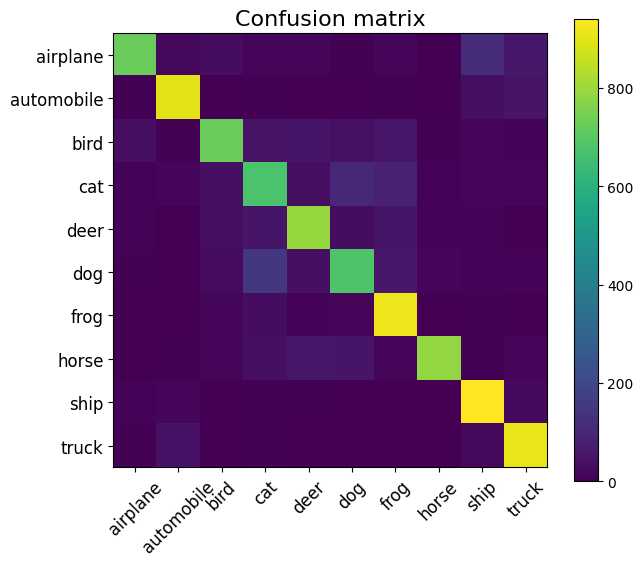

Test accuracy: 0.8042


In [146]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

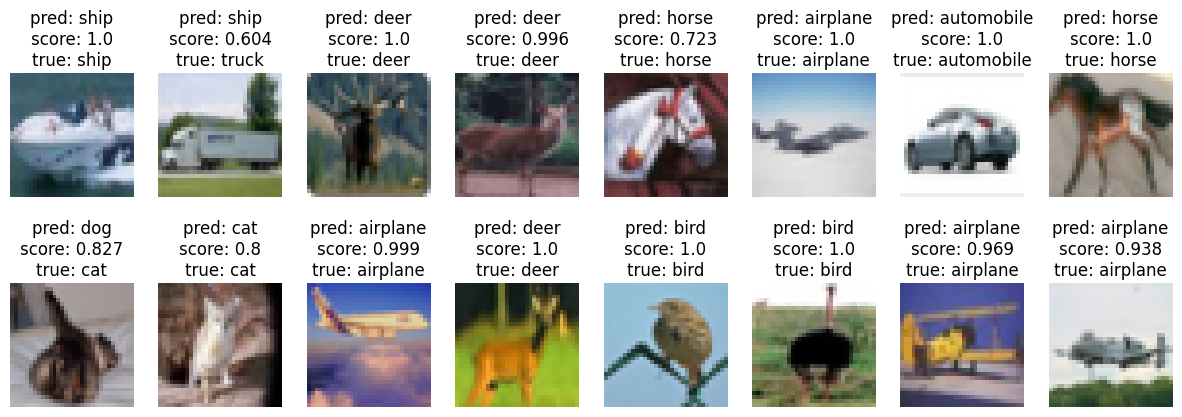

In [147]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons, 
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ - 
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


